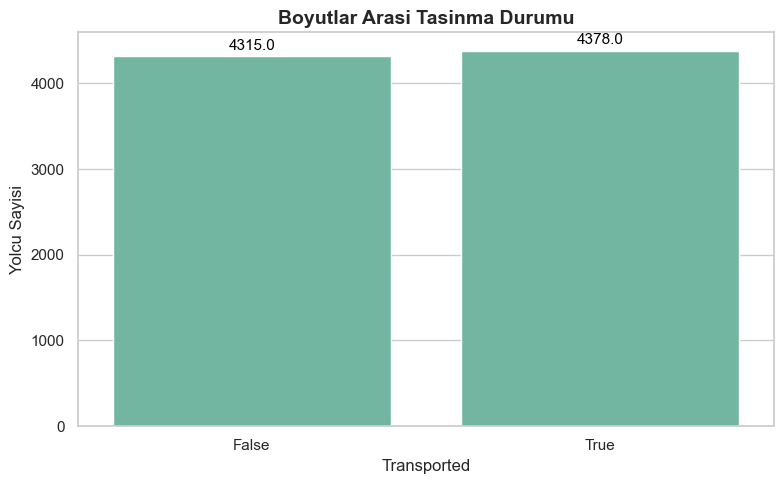

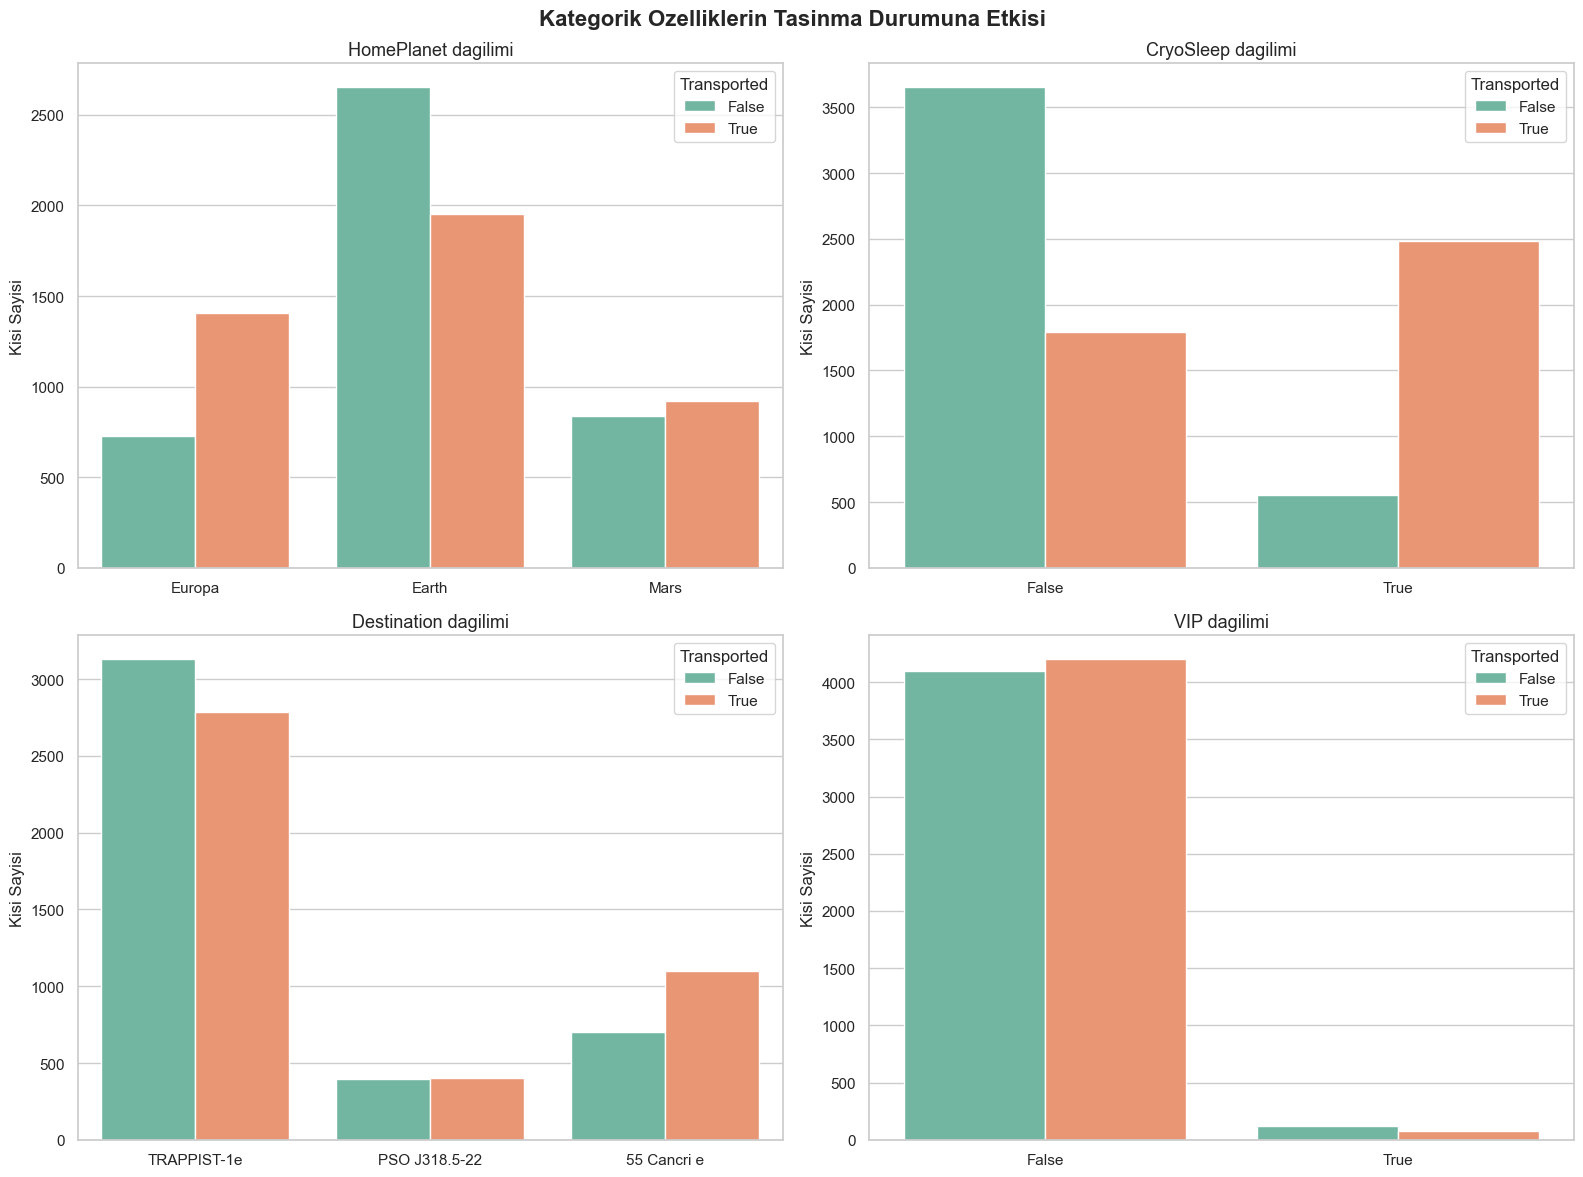

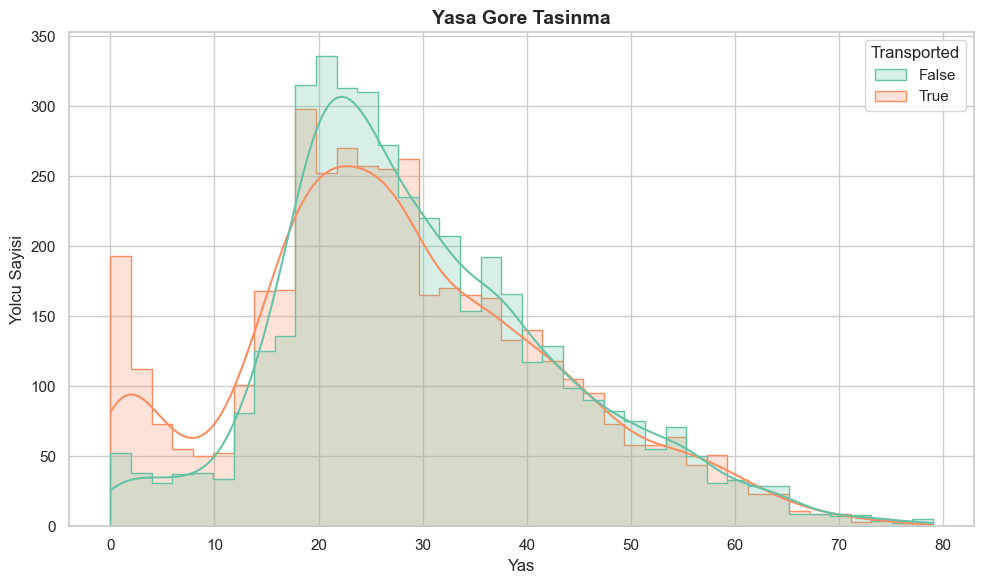

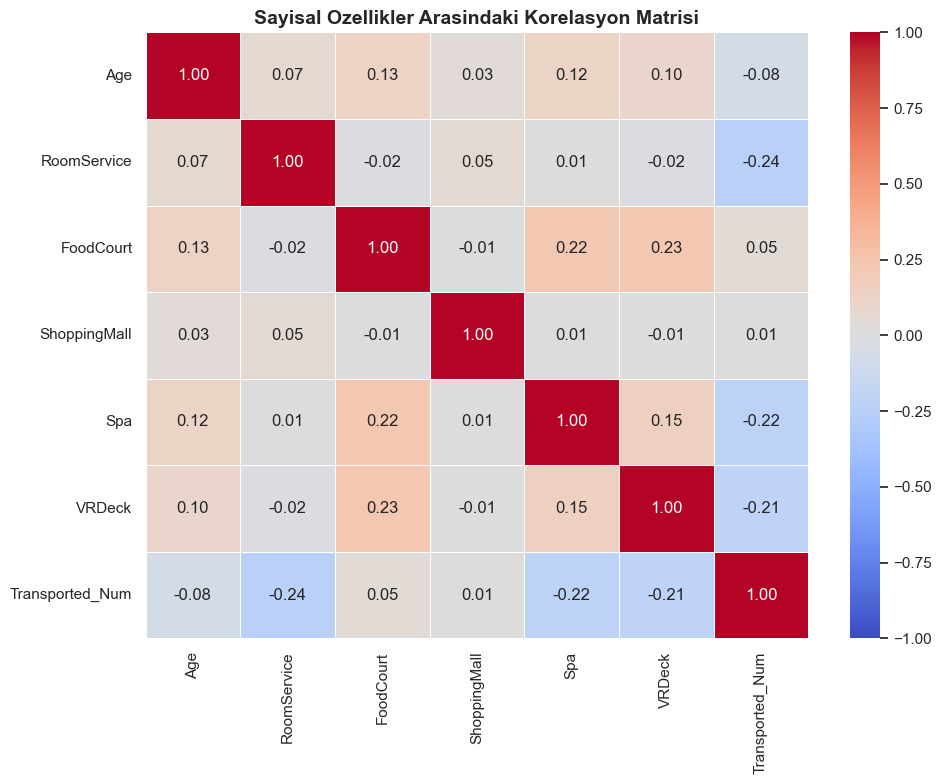

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# tema
sns.set_theme(style="whitegrid", palette="Set2")

train_df = pd.read_csv("train.csv")

# transported dagilimini gormek icin tablo gorsellistirmesi
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=train_df, x='Transported')
plt.title('Boyutlar Arasi Tasinma Durumu', fontsize=14, fontweight='bold')
plt.xlabel('Transported', fontsize=12)
plt.ylabel('Yolcu Sayisi', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

# kategorik degisken - hedef iliskisi
cat_features = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Kategorik Ozelliklerin Tasinma Durumuna Etkisi', fontsize=16, fontweight='bold')

for i, col in enumerate(cat_features):
    ax = axes[i//2, i%2]
    sns.countplot(data=train_df, x=col, hue='Transported', ax=ax)
    ax.set_title(f'{col} dagilimi', fontsize=13)
    ax.set_xlabel('')
    ax.set_ylabel('Kisi Sayisi')

plt.tight_layout()
plt.show()

# yas dagilimi icin tablo
plt.figure(figsize=(10, 6))
sns.histplot(data=train_df, x='Age', hue='Transported', bins=40, kde=True, element="step")
plt.title('Yasa Gore Tasinma', fontsize=14, fontweight='bold')
plt.xlabel('Yas', fontsize=12)
plt.ylabel('Yolcu Sayisi', fontsize=12)
plt.tight_layout()
plt.show()

# transported hedefini numerik hale getirme
train_df['Transported_Num'] = train_df['Transported'].astype(int)

# sayisal sutun secimi
num_features = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Transported_Num']
corr = train_df[num_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1, vmax=1)
plt.title('Sayisal Ozellikler Arasindaki Korelasyon Matrisi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

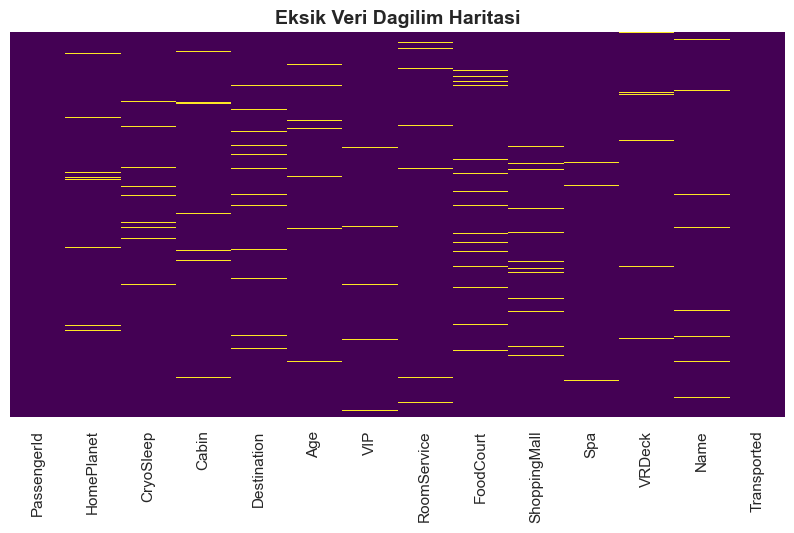

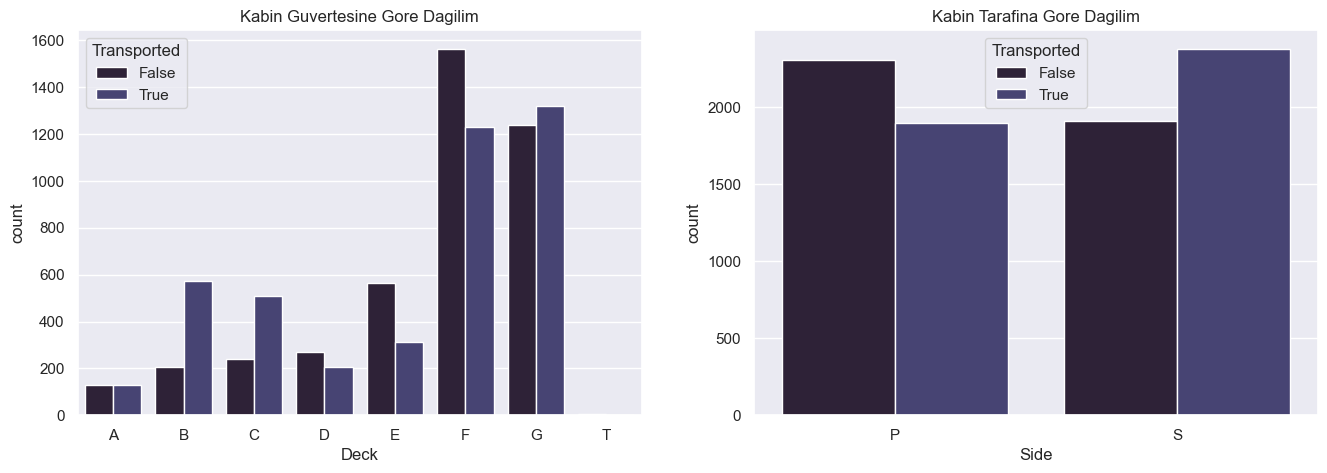

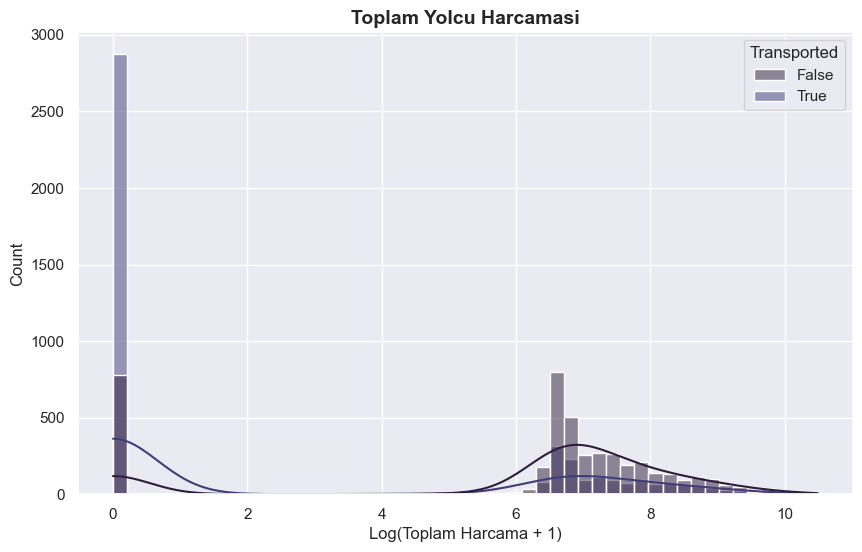

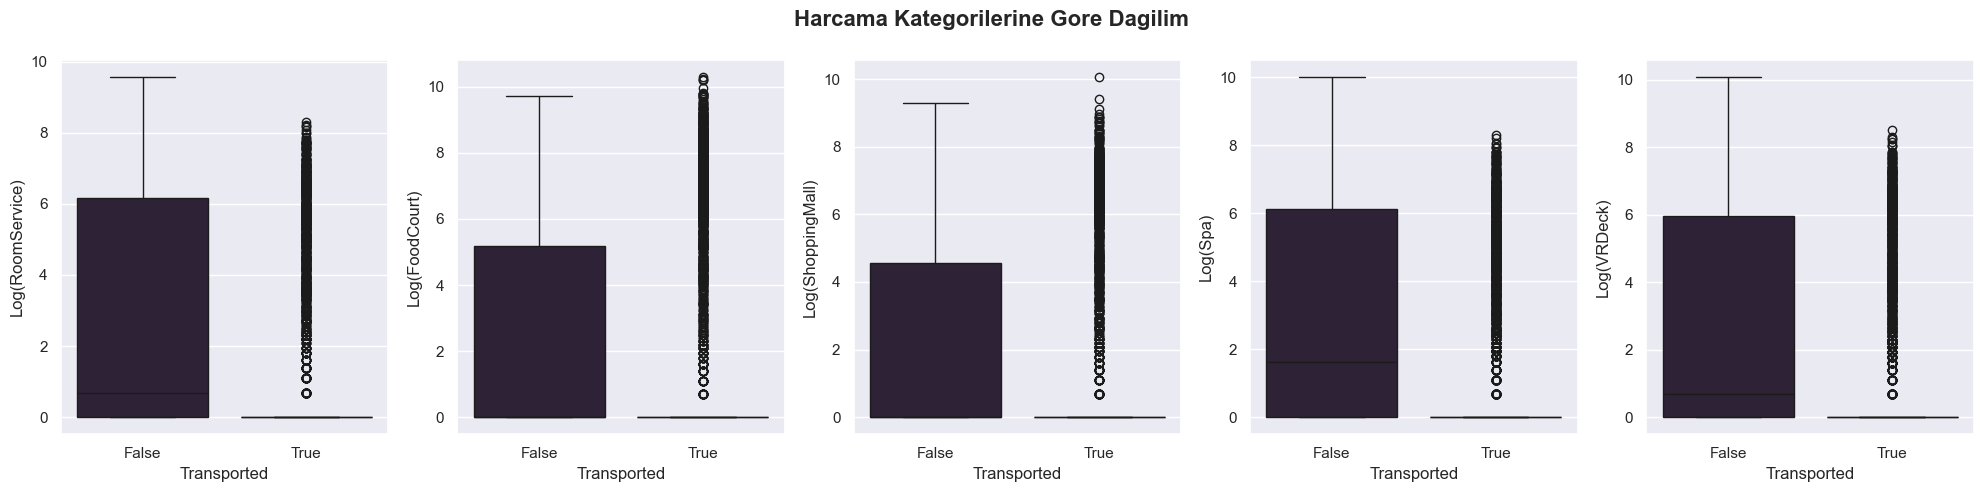

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# tema
sns.set_theme(style="darkgrid", palette="mako")

train_df = pd.read_csv("train.csv")

# eksik verileri inceleme
plt.figure(figsize=(10, 5))
sns.heatmap(train_df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Eksik Veri Dagilim Haritasi', fontsize=14, fontweight='bold')
plt.show()

# kabin degiskenini deck, num, side olarak uce bolmek (analiz yaparken bu degiskenleri teker teker inceleyebilmek icin)
train_df[['Deck', 'Num', 'Side']] = train_df['Cabin'].str.split('/', expand=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
deck_order = train_df['Deck'].dropna().sort_values().unique()

sns.countplot(data=train_df, x='Deck', hue='Transported', order=deck_order, ax=axes[0])
axes[0].set_title('Kabin Guvertesine Gore Dagilim')

sns.countplot(data=train_df, x='Side', hue='Transported', ax=axes[1])
axes[1].set_title('Kabin Tarafina Gore Dagilim')
plt.show()

# toplam harcama davranisinin birlestirilmesi
luxury_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
train_df['TotalExpenditure'] = train_df[luxury_cols].sum(axis=1)

plt.figure(figsize=(10, 6))

# sifir degerleri hesaplamayi bozmasin diye log(p+1) kullanimi
sns.histplot(x=np.log1p(train_df['TotalExpenditure']), hue=train_df['Transported'], bins=50, kde=True)
plt.title('Toplam Yolcu Harcamasi', fontsize=14, fontweight='bold')
plt.xlabel('Log(Toplam Harcama + 1)')
plt.show()

# aykiri deger analizi
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, col in enumerate(luxury_cols):
    sns.boxplot(y=np.log1p(train_df[col]), x=train_df['Transported'], ax=axes[i])
    axes[i].set_ylabel(f'Log({col})')
plt.suptitle('Harcama Kategorilerine Gore Dagilim', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

2.

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("train.csv")

# soyadlarindan eksik deger doldurabilmek icin isim ozniteligini isim ve soyisim olarak ayirma islemi
df[['FirstName', 'Surname']] = df['Name'].str.split(' ', expand=True)
df['Group'] = df['PassengerId'].apply(lambda x: x.split('_')[0])

# harcamalari birlestirme islemi (tek olarak harcamalarin bir degeri olmadigi dusunulmustur)
expense_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
df['Total_Expense'] = df[expense_cols].sum(axis=1)

# eksik veri doldurma islemleri
# homeplanet doldurma islemleri
# ayni gruptan gelenler ayni gezegenden gelmistir mantigi ile doldurma
group_planet = df.dropna(subset=['HomePlanet']).groupby('Group')['HomePlanet'].first().to_dict()
df['HomePlanet'] = df['HomePlanet'].fillna(df['Group'].map(group_planet))

# geri kalan bosluklara soyismi ayni olanlar ayni gezegenden gelmistir mantigi ile doldurma
surname_planet = df.dropna(subset=['HomePlanet']).groupby('Surname')['HomePlanet'].first().to_dict()
df['HomePlanet'] = df['HomePlanet'].fillna(df['Surname'].map(surname_planet))

# cryosleep doldurma islemleri
# eger yolcu harcama yaptiysa uyumuyordur mantigi ile doldurma
df.loc[(df['CryoSleep'].isnull()) & (df['Total_Expense'] > 0), 'CryoSleep'] = False

# ayni odada kalanlar ayni cryosleep durumundadir mantigina gore doldurma islemleri
cabin_cryo_nunique = df.dropna(subset=['CryoSleep']).groupby('Cabin')['CryoSleep'].nunique()
pure_cabins = cabin_cryo_nunique[cabin_cryo_nunique == 1].index
cabin_cryo_map = df[df['Cabin'].isin(pure_cabins)].groupby('Cabin')['CryoSleep'].first().to_dict()
df['CryoSleep'] = df['CryoSleep'].fillna(df['Cabin'].map(cabin_cryo_map))

# kalan azinlik icin insiyatif alinarak hic harcama yapmamislarsa uyuyor, keri kalanlar ise uyumuyor seklinde doldurulmustur
df.loc[(df['CryoSleep'].isnull()) & (df['Total_Expense'] == 0), 'CryoSleep'] = True
df['CryoSleep'] = df['CryoSleep'].fillna(False)

# kabin doldurma islemleri
# soyismi ayni olan aileleri ayni kabine koyma islemi
def get_mode(x):
    m = pd.Series.mode(x)
    return m.iloc[0] if not m.empty else np.nan

surname_cabin_map = df.dropna(subset=['Cabin']).groupby('Surname')['Cabin'].agg(get_mode).to_dict()
df['Cabin'] = df['Cabin'].fillna(df['Surname'].map(surname_cabin_map))

# destination doldurma islemleri
# ayni aileden ise ayni yere gidiyordur mantigi ile doldurma
surname_dest_map = df.dropna(subset=['Destination']).groupby('Surname')['Destination'].agg(get_mode).to_dict()
df['Destination'] = df['Destination'].fillna(df['Surname'].map(surname_dest_map))

# yas doldurma islemleri
# geldikleri homeplanet'e gore yas medyani alarak doldurma islemi
df['Age'] = df.groupby('HomePlanet')['Age'].transform(lambda x: x.fillna(x.median()))

# kalan degerler genel medyan ile doldurulur
df['Age'] = df['Age'].fillna(df['Age'].median())

# vip doldurma islemleri
# ayni kabinde kalanlari ayni vip durumuna gore doldurma islemi
cabin_vip_map = df.dropna(subset=['VIP']).groupby('Cabin')['VIP'].agg(lambda x: any(x)).to_dict()
df['VIP'] = df['VIP'].fillna(df['Cabin'].map(cabin_vip_map))
df['VIP'] = df['VIP'].fillna(False) # Kalan tüm VIP'ler azınlık olduğu için False kabul edildi.

# az kalan degerler olduysa silme islemi
# homeplanet (12 kisi), cabin (11 kisi) ve destination (12 kisi)
df = df.dropna(subset=['HomePlanet', 'Cabin', 'Destination'])

# kabini parcalama islemi
df[['Deck', 'Num', 'Side']] = df['Cabin'].str.split('/', expand=True)

print(df.isnull().sum())

PassengerId        0
HomePlanet         0
CryoSleep          0
Cabin              0
Destination        0
Age                0
VIP                0
RoomService      181
FoodCourt        181
ShoppingMall     206
Spa              182
VRDeck           188
Name             190
Transported        0
FirstName        190
Surname          190
Group              0
Total_Expense      0
Deck               0
Num                0
Side               0
dtype: int64


In [4]:
# harcama sutunlari listesi
expense_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

for col in expense_cols:
    # cryosleep olanlarin harcamasi 0
    df.loc[(df['CryoSleep'] == True) & (df[col].isnull()), col] = 0

    # 13 yasindan kucuklerin harcamasi 0
    df.loc[(df['Age'] < 13) & (df[col].isnull()), col] = 0

    # kalan bosluklari vip veya homeplanet'e gore medyan alarak doldurma
    df[col] = df.groupby(['VIP', 'HomePlanet'])[col].transform(lambda x: x.fillna(x.median()))

    # eger spesifik olarak hic veri bulunamamissa kalan azinlik bosluklar vip durumuna gore doldurulur
    df[col] = df.groupby('VIP')[col].transform(lambda x: x.fillna(x.median()))

    # hala bosluk kalmissa genel medyana gore doldurulur
    df[col] = df[col].fillna(df[col].median())

# tum harcamalar dolduruluktan sonra total_expense guncellenir
df['Total_Expense'] = df[expense_cols].sum(axis=1)

print("Harcama sutunlarindaki eksik veri kontrolu:")
print(df[expense_cols].isnull().sum())

Harcama sutunlarindaki eksik veri kontrolu:
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
dtype: int64


In [5]:
# ise yaramayacak veya yenileri uretilen eski sutunlarin silinmesi
cols_to_drop = ['Name', 'FirstName', 'Surname', 'Cabin', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# errors='ignore' eger o sutun zaten silinmisse hata vermesini engeller
df = df.drop(columns=cols_to_drop, errors='ignore')

print("Kalan sutunlar:", df.columns.tolist())
print(df.head().to_string())

Kalan sutunlar: ['PassengerId', 'HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'Transported', 'Group', 'Total_Expense', 'Deck', 'Num', 'Side']
  PassengerId HomePlanet CryoSleep  Destination   Age    VIP  Transported Group  Total_Expense Deck Num Side
0     0001_01     Europa     False  TRAPPIST-1e  39.0  False        False  0001            0.0    B   0    P
1     0002_01      Earth     False  TRAPPIST-1e  24.0  False         True  0002          736.0    F   0    S
2     0003_01     Europa     False  TRAPPIST-1e  58.0   True        False  0003        10383.0    A   0    S
3     0003_02     Europa     False  TRAPPIST-1e  33.0  False        False  0003         5176.0    A   0    S
4     0004_01      Earth     False  TRAPPIST-1e  16.0  False         True  0004         1091.0    F   1    S


In [6]:
# one-hot encoding
# cryosleep, vip ve transportedin numeriklestirilmesi
bool_cols = ['CryoSleep', 'VIP', 'Transported']
for col in bool_cols:
    df[col] = df[col].astype(int)

df['Num'] = df['Num'].astype(int)
df['Group'] = df['Group'].astype(int)
cat_cols = ['HomePlanet', 'Destination', 'Deck', 'Side']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

# passengerid ise yaramadigi icin siliyoruz
df = df.drop(columns=['PassengerId'], errors='ignore')

print("Yeni sutun sayisi:", len(df.columns))
print(df.head())

Yeni sutun sayisi: 19
   CryoSleep   Age  VIP  Transported  Group  Total_Expense  Num  \
0          0  39.0    0            0      1            0.0    0   
1          0  24.0    0            1      2          736.0    0   
2          0  58.0    1            0      3        10383.0    0   
3          0  33.0    0            0      3         5176.0    0   
4          0  16.0    0            1      4         1091.0    1   

   HomePlanet_Europa  HomePlanet_Mars  Destination_PSO J318.5-22  \
0                  1                0                          0   
1                  0                0                          0   
2                  1                0                          0   
3                  1                0                          0   
4                  0                0                          0   

   Destination_TRAPPIST-1e  Deck_B  Deck_C  Deck_D  Deck_E  Deck_F  Deck_G  \
0                        1       1       0       0       0       0       0   
1         

In [7]:
# csv olarak kaydetme
df.to_csv("final_train_data.csv", index=False)